In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("03-2025.csv")

In [7]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,73996739445,2025-03-01 02:29,Inbound,00:00:00,NaN,NaN
1,74000820503,2025-03-01 09:44,Inbound,00:00:00,NaN,NaN
2,74014583710,2025-03-01 10:58,Outbound,00:00:08,NaN,Kevin Nuesi
3,74008762243,2025-03-01 11:01,Outbound,00:00:04,NaN,Sam Steindorf
4,74014585436,2025-03-01 11:01,Outbound,00:00:00,NaN,Kevin Nuesi


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12405 entries, 0 to 12404
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             12405 non-null  int64  
 1   Activity date         12405 non-null  str    
 2   Call direction        11692 non-null  str    
 3   Call duration         11672 non-null  str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  11837 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.1 MB


In [11]:
df1 = df.drop(columns=['hs_call_outcome','Record ID'])

In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 12405 entries, 0 to 12404
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         12405 non-null  str  
 1   Call direction        11692 non-null  str  
 2   Call duration         11672 non-null  str  
 3   Activity assigned to  11837 non-null  str  
dtypes: str(4)
memory usage: 899.4 KB


In [15]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format = "%Y-%m-%d %H:%M",
    errors='coerce'
)

In [17]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 12405 entries, 0 to 12404
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         12405 non-null  datetime64[us]
 1   Call direction        11692 non-null  str           
 2   Call duration         11672 non-null  str           
 3   Activity assigned to  11837 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 705.6 KB


# Call Count per Day

In [20]:
df2 = df1.copy()

In [22]:
df2['date'] = df2['Activity date'].dt.date

In [24]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-03-01 02:29:00,Inbound,00:00:00,NaN,2025-03-01
1,2025-03-01 09:44:00,Inbound,00:00:00,NaN,2025-03-01
2,2025-03-01 10:58:00,Outbound,00:00:08,Kevin Nuesi,2025-03-01
3,2025-03-01 11:01:00,Outbound,00:00:04,Sam Steindorf,2025-03-01
4,2025-03-01 11:01:00,Outbound,00:00:00,Kevin Nuesi,2025-03-01


In [26]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [28]:
daily_calls.head()

,date,call_count
0,2025-03-01,34
1,2025-03-02,20
2,2025-03-03,405
3,2025-03-04,242
4,2025-03-05,441


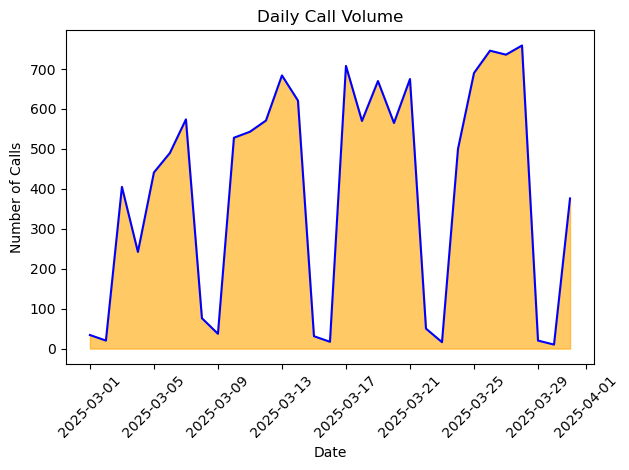

In [30]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [33]:
df1['day'] = df1['Activity date'].dt.day_name()

In [35]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-03-01 02:29:00,Inbound,00:00:00,NaN,Saturday
1,2025-03-01 09:44:00,Inbound,00:00:00,NaN,Saturday
2,2025-03-01 10:58:00,Outbound,00:00:08,Kevin Nuesi,Saturday
3,2025-03-01 11:01:00,Outbound,00:00:04,Sam Steindorf,Saturday
4,2025-03-01 11:01:00,Outbound,00:00:00,Kevin Nuesi,Saturday


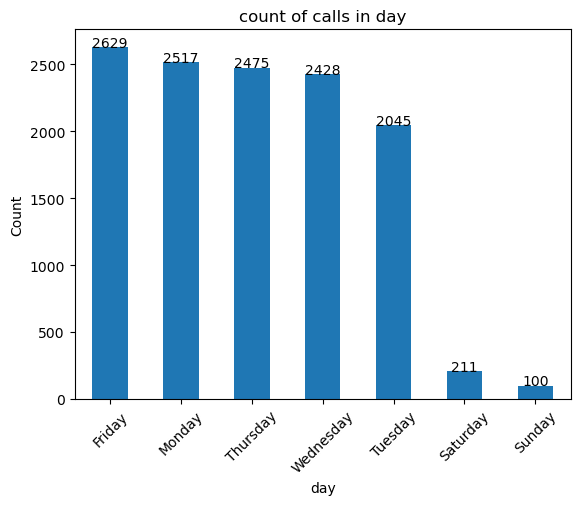

In [37]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

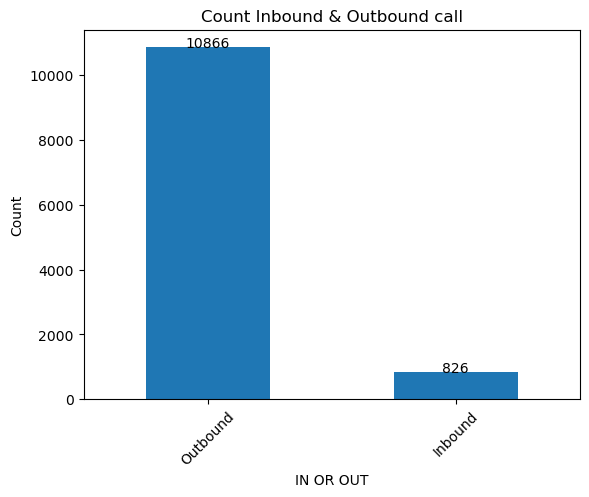

In [40]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel("IN OR OUT")
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [43]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

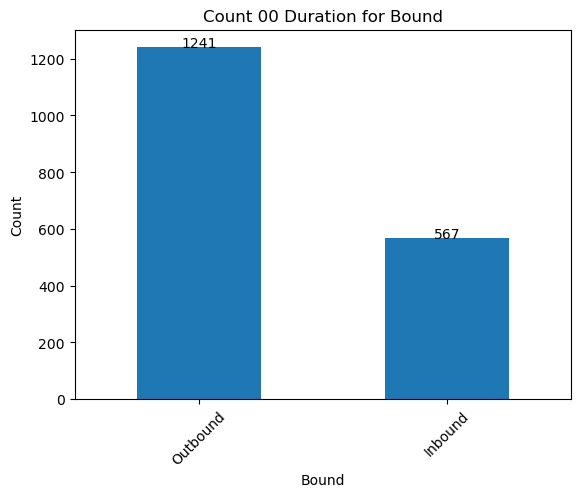

In [45]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call Direction

In [48]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
62,2025-03-03 09:17:00,Inbound,NaN,Robin Stoehr,Monday
544,2025-03-04 13:57:00,Outbound,NaN,Christian Banks,Tuesday
558,2025-03-04 14:08:00,Outbound,NaN,Christian Banks,Tuesday
587,2025-03-04 15:07:00,Outbound,NaN,Christian Banks,Tuesday
589,2025-03-04 15:14:00,Outbound,NaN,Christian Banks,Tuesday
...,...,...,...,...,...
12010,2025-03-29 15:00:00,Outbound,NaN,Sam Steindorf,Saturday
12011,2025-03-29 15:00:00,Outbound,NaN,Sam Steindorf,Saturday
12012,2025-03-29 15:30:00,Outbound,NaN,Sam Steindorf,Saturday
12013,2025-03-29 15:30:00,Outbound,NaN,Sam Steindorf,Saturday


In [50]:
df4 = df1.copy()

In [52]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [54]:
(df4['Call duration'] == 0).sum()

1808

In [56]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [58]:
df4 = df4.dropna(subset = ['Call direction'])

In [60]:
(df4['Call duration'] == 0).sum()

1923

In [62]:
df4.info()

<class 'pandas.DataFrame'>
Index: 11692 entries, 0 to 12404
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         11692 non-null  datetime64[us]
 1   Call direction        11692 non-null  str           
 2   Call duration         11692 non-null  float64       
 3   Activity assigned to  11135 non-null  str           
 4   day                   11692 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 847.7 KB


# Working Call Assigner

In [65]:
df1['Activity assigned to'].nunique()

26

In [67]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[                nan,       'Kevin Nuesi',     'Sam Steindorf',
      'David Valdez',         'Terry Kim',    'Boston Hoppman',
      'Robin Stoehr',    'Cameron Dudley',   'Christian Banks',
     'Keith Antonio',     'Garrett Evans',   'Blake Roudebush',
     'Oliver Martin',       'Tyler Smith',        'Tyler Jury',
    'David Banister', 'Brittany Digiulio',   'Spenser Szakacs',
  'Chrystel Manabat',         'Juan Calo',       'Jon Karimov',
   'Adonis Baybayan',      'Bill Goodwin',            'Abhi C',
    'Nick Rothacher',       'Paol Guzman',          'June Kim']
Length: 27, dtype: str

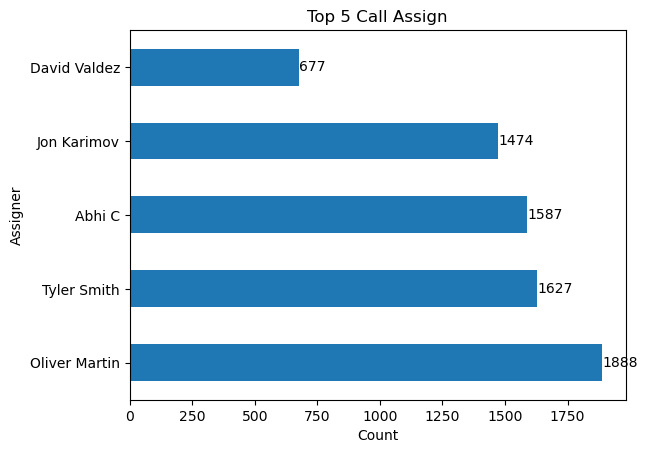

In [69]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [72]:
df4['Call duration'].max()

94.1

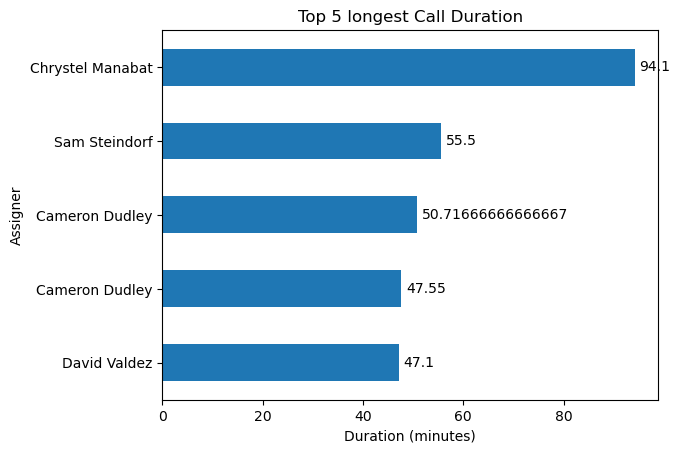

In [74]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [77]:
df3 = df1.copy()

In [79]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [81]:
df3['day'].unique()

<ArrowStringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 5, dtype: str

In [83]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

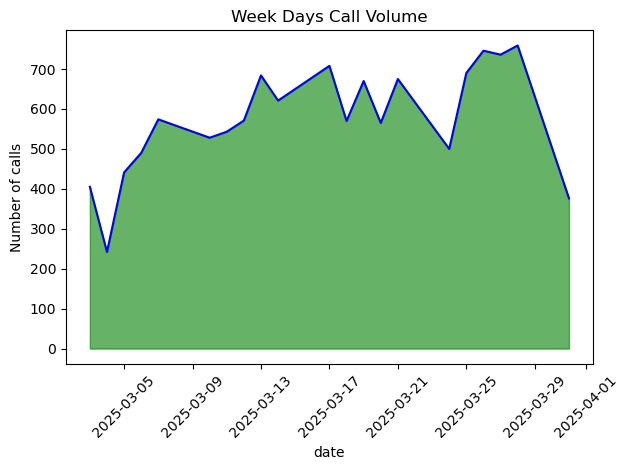

In [85]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKED TIME DURATION

In [88]:
df5=df4.copy()

In [90]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [92]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-03-01 02:29:00,Inbound,0.000000,NaN,Saturday
1,2025-03-01 09:44:00,Inbound,0.000000,NaN,Saturday
2,2025-03-01 10:58:00,Outbound,0.133333,Kevin Nuesi,Saturday
3,2025-03-01 11:01:00,Outbound,0.066667,Sam Steindorf,Saturday
4,2025-03-01 11:01:00,Outbound,0.000000,Kevin Nuesi,Saturday


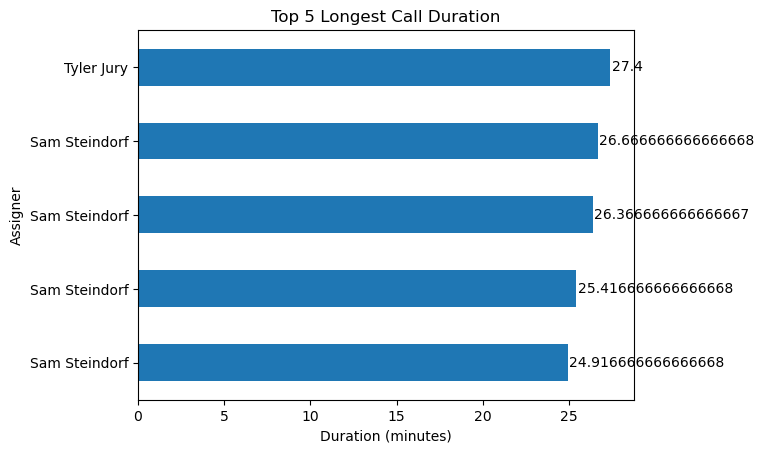

In [94]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

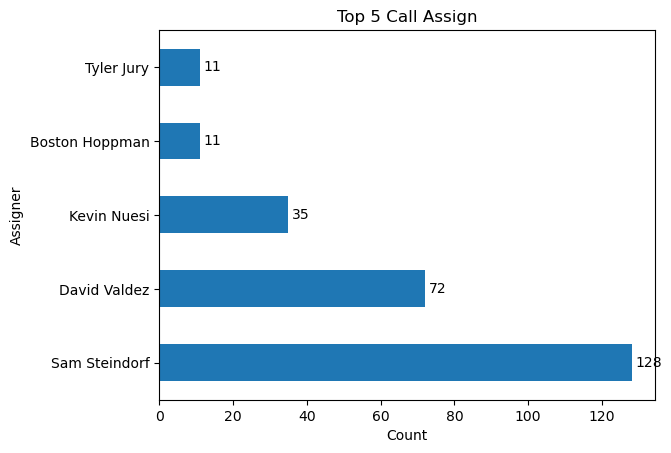

In [97]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [100]:
df4["Call duration"].mean()

1.7086668947428438

In [102]:
df4["Call duration"].median()

0.11666666666666667

# Without Call Assigner Calls

In [105]:
df6 = df3.copy()

In [107]:
df6['month'] = df6['Activity date'].dt.month_name()

In [109]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

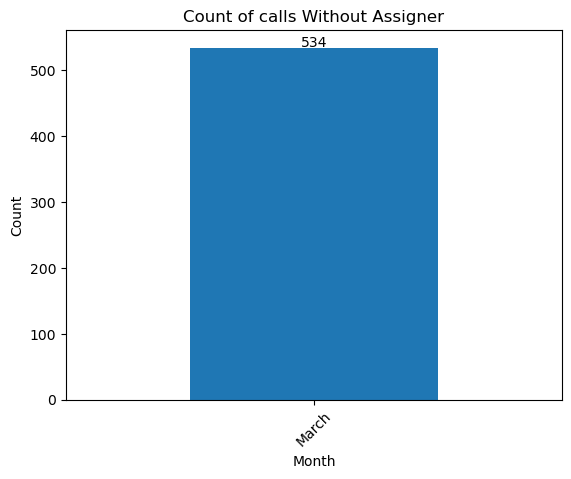

In [111]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call Date

In [114]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [116]:
top5 = daily_calls.sort_values(ascending=False).head(5)

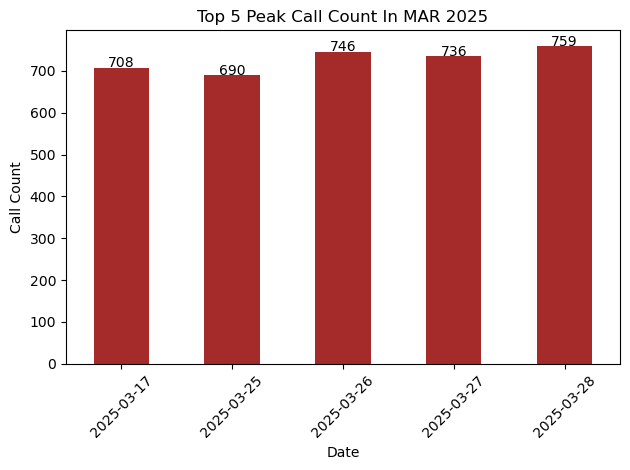

In [120]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In MAR 2025")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()